<a href="https://colab.research.google.com/github/alyaaahmed019/Named-Entity-Recognition-NER-from-News-Articles/blob/main/task__3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
alaakhaled_conll003_englishversion_path = kagglehub.dataset_download('alaakhaled/conll003-englishversion')

print('Data source import complete.')


In [ ]:
!python -m spacy download en_core_web_lg

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.7/400.7 MB 4.0 MB/s eta 0:00:0000:0100:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_lg')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

# Data reading

In [ ]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/datasets/alaakhaled/conll003-englishversion/valid.txt
/kaggle/input/datasets/alaakhaled/conll003-englishversion/metadata
/kaggle/input/datasets/alaakhaled/conll003-englishversion/test.txt
/kaggle/input/datasets/alaakhaled/conll003-englishversion/train.txt


In [ ]:
# ============================================================================
# 1. DATA PREPROCESSING
# ============================================================================
def load_conll_data(file_path):
    sentences = []
    labels = []
    current_sentence = []
    current_labels = []

    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()

            if not line:
                if current_sentence:
                    sentences.append(current_sentence)
                    labels.append(current_labels)
                    current_sentence = []
                    current_labels = []
                continue

            if line.startswith('-DOCSTART-'):
                continue

            parts = line.split()
            if len(parts) >= 4:
                word = parts[0]
                ner_tag = parts[3]
                current_sentence.append(word)
                current_labels.append(ner_tag)

    if current_sentence:
        sentences.append(current_sentence)
        labels.append(current_labels)

    return sentences, labels

In [ ]:
# Load data (keep them separate)
train_sentences, train_labels = load_conll_data(
    '/kaggle/input/datasets/alaakhaled/conll003-englishversion/train.txt'
)
valid_sentences, valid_labels = load_conll_data(
    '/kaggle/input/datasets/alaakhaled/conll003-englishversion/test.txt'
)
test_sentences, test_labels = load_conll_data(
    '/kaggle/input/datasets/alaakhaled/conll003-englishversion/test.txt'
)
print(f"Training sentences: {len(train_sentences)}")
print(f"Validation sentences: {len(valid_sentences)}")
print(f"Test sentences: {len(test_sentences)}")
print("\nSample sentence:")
print(train_sentences[0])
print("\nSample labels:")
print(train_labels[0])

Training sentences: 14041
Validation sentences: 3453
Test sentences: 3453

Sample sentence:
['EU', 'rejects', 'German', 'call', 'to', 'boycott', 'British', 'lamb', '.']

Sample labels:
['B-ORG', 'O', 'B-MISC', 'O', 'O', 'O', 'B-MISC', 'O', 'O']


#  EXPLORATORY DATA ANALYSIS

=== Label Distribution (Train) ===
  B-LOC          :   7140
  B-MISC         :   3438
  B-ORG          :   6321
  B-PER          :   6600
  I-LOC          :   1157
  I-MISC         :   1155
  I-ORG          :   3704
  I-PER          :   4528
  O              : 169578


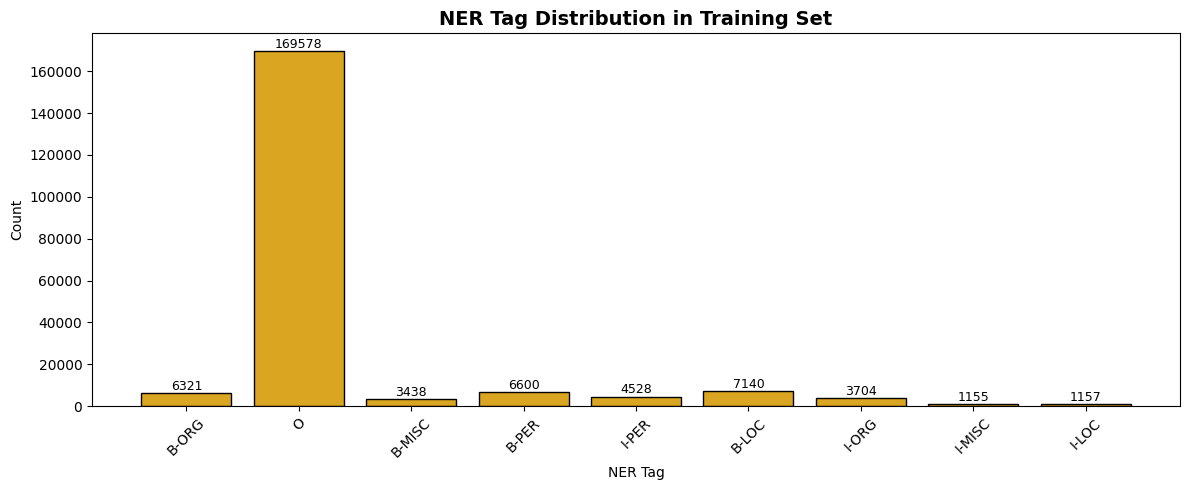

In [ ]:
from collections import Counter

def get_entity_stats(labels):
    all_tags = [tag for sent in labels for tag in sent]
    return Counter(all_tags)

train_stats = get_entity_stats(train_labels)
print("=== Label Distribution (Train) ===")
for tag, count in sorted(train_stats.items()):
    print(f"  {tag:15s}: {count:6d}")

# Visualize distribution
tags = list(train_stats.keys())
counts = list(train_stats.values())

plt.figure(figsize=(12, 5))
bars = plt.bar(tags, counts, color='goldenrod', edgecolor='black')
plt.title('NER Tag Distribution in Training Set', fontsize=14, fontweight='bold')
plt.xlabel('NER Tag')
plt.ylabel('Count')


for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
             str(count), ha='center', va='bottom', fontsize=9)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('tag_distribution.png', dpi=150)
plt.show()

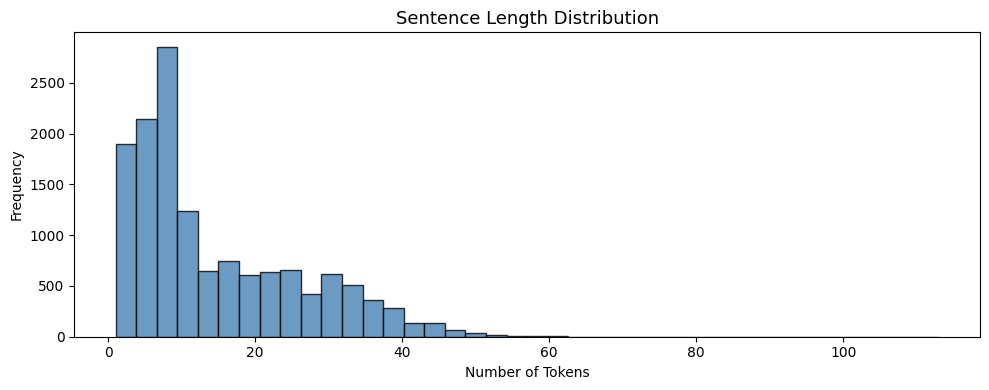


Avg sentence length : 14.5 tokens
Max sentence length : 113 tokens


In [ ]:
# Sentence length distribution
sent_lengths = [len(s) for s in train_sentences]
plt.figure(figsize=(10, 4))
plt.hist(sent_lengths, bins=40, color='steelblue', edgecolor='black', alpha=0.8)
plt.title('Sentence Length Distribution', fontsize=13)
plt.xlabel('Number of Tokens')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('sentence_lengths.png', dpi=150)
plt.show()

print(f"\nAvg sentence length : {np.mean(sent_lengths):.1f} tokens")
print(f"Max sentence length : {max(sent_lengths)} tokens")

# RULE-BASED NER

In [ ]:
# Small demo lists

locations = {
    "Germany", "France", "London", "Paris", "USA", "Egypt",
    "China", "Japan", "Italy", "Spain"}

org_keywords = {
    "Inc", "Ltd", "Corp", "Company", "Bank",
    "University", "Club", "Committee", "Agency"}

sports_keywords = {
    "CRICKET", "SOCCER", "RUGBY", "TENNIS"}


def rule_based_model(tokens):
    predictions = ["O"] * len(tokens)
    i = 0

    while i < len(tokens):
        token = tokens[i]

        # =========================
        # 1️⃣ LOCATION RULE
        # =========================
        if token in locations:
            predictions[i] = "B-LOC"
            i += 1
            continue

        # =========================
        # 2️⃣ ORGANIZATION RULE
        # Consecutive ALL CAPS words
        # =========================
        if token.isupper() and token not in sports_keywords and len(token) > 2:
            predictions[i] = "B-ORG"
            j = i + 1

            while j < len(tokens) and tokens[j].isupper():
                predictions[j] = "I-ORG"
                j += 1

            i = j
            continue

        # =========================
        # 3️⃣ ORGANIZATION KEYWORDS
        # =========================
        if token in org_keywords:
            predictions[i] = "B-ORG"
            i += 1
            continue

        # =========================
        # 4️⃣ PERSON RULE
        # Two consecutive Title case words
        # =========================
        if token.istitle():
            if i+1 < len(tokens) and tokens[i+1].istitle():
                predictions[i] = "B-PER"
                predictions[i+1] = "I-PER"
                i += 2
                continue
            else:
                predictions[i] = "B-PER"
                i += 1
                continue

        i += 1

    return predictions

In [ ]:
for tokens, true_labels in zip(valid_sentences[:3], valid_labels[:3]):
    pred_labels = rule_based_model(tokens)

    print("Tokens:", tokens)
    print("True  :", true_labels)
    print("Pred  :", pred_labels)
    print("-" * 80)

Tokens: ['SOCCER', '-', 'JAPAN', 'GET', 'LUCKY', 'WIN', ',', 'CHINA', 'IN', 'SURPRISE', 'DEFEAT', '.']
True  : ['O', 'O', 'B-LOC', 'O', 'O', 'O', 'O', 'B-PER', 'O', 'O', 'O', 'O']
Pred  : ['O', 'O', 'B-ORG', 'I-ORG', 'I-ORG', 'I-ORG', 'O', 'B-ORG', 'I-ORG', 'I-ORG', 'I-ORG', 'O']
--------------------------------------------------------------------------------
Tokens: ['Nadim', 'Ladki']
True  : ['B-PER', 'I-PER']
Pred  : ['B-PER', 'I-PER']
--------------------------------------------------------------------------------
Tokens: ['AL-AIN', ',', 'United', 'Arab', 'Emirates', '1996-12-06']
True  : ['B-LOC', 'O', 'B-LOC', 'I-LOC', 'I-LOC', 'O']
Pred  : ['B-ORG', 'O', 'B-PER', 'I-PER', 'B-PER', 'O']
--------------------------------------------------------------------------------


## model evaluation

In [ ]:
true_all = []
pred_all = []

for tokens, true_labels in zip(valid_sentences, valid_labels):
    pred_labels = rule_based_model(tokens)

    true_all.extend(true_labels)
    pred_all.extend(pred_labels)

from sklearn.metrics import classification_report
print(classification_report(true_all, pred_all))

              precision    recall  f1-score   support

       B-LOC       0.93      0.14      0.24      1668
      B-MISC       0.00      0.00      0.00       702
       B-ORG       0.39      0.24      0.30      1661
       B-PER       0.23      0.93      0.37      1617
       I-LOC       0.00      0.00      0.00       257
      I-MISC       0.00      0.00      0.00       216
       I-ORG       0.05      0.05      0.05       835
       I-PER       0.47      0.86      0.61      1156
           O       0.99      0.92      0.96     38323

    accuracy                           0.83     46435
   macro avg       0.34      0.35      0.28     46435
weighted avg       0.89      0.83      0.84     46435



# MODEL-BASED NER — spaCy small model

In [ ]:
import spacy
from spacy import displacy

print("Loading spaCy models …")
nlp_sm = spacy.load('en_core_web_sm')   # small
nlp_lg = spacy.load('en_core_web_lg')   # large  ← bonus comparison

Loading spaCy models …


In [ ]:
def smart_case_fix(tokens):
    text = " ".join(tokens)
    letters = [c for c in text if c.isalpha()]

    # If 80%+ letters are uppercase → fix
    if letters and sum(c.isupper() for c in letters) / len(letters) > 0.8:
        new_tokens = []
        for token in tokens:
            if token.isupper() and len(token) <= 3:
                new_tokens.append(token)  # keep acronyms (EU, USA)
            else:
                new_tokens.append(token.lower().capitalize())
        return new_tokens

    return tokens

In [ ]:
def apply_case_fix(dataset):
    return [smart_case_fix(sentence) for sentence in dataset]

train_sentences_fixed = apply_case_fix(train_sentences)
valid_sentences_fixed = apply_case_fix(valid_sentences)
test_sentences_fixed  = apply_case_fix(test_sentences)

In [ ]:
def spacy_to_bio(doc, tokens):
    bio_labels = ["O"] * len(tokens)

    for ent in doc.ents:
        label = ent.label_

        # Mapping
        if label == "PERSON":
            mapped = "PER"
        elif label == "ORG":
            mapped = "ORG"
        elif label in ["GPE", "LOC"]:
            mapped = "LOC"
        elif label in ["NORP", "EVENT", "WORK_OF_ART", "LAW"]:
            mapped = "MISC"
        else:
            continue   # skip unknown labels instead of forcing MISC"
        # Post-processing rule
        if mapped == "ORG":
            first_token = doc[ent.start]
            if first_token.text in ["Mr.", "Mrs.", "Dr.", "President"]:
                mapped = "PER"


        start = ent.start
        end = ent.end

        bio_labels[start] = "B-" + mapped
        for i in range(start + 1, end):
            bio_labels[i] = "I-" + mapped

    return bio_labels

In [ ]:
def spacy_predict(dataset , nlp):
    all_true = []
    all_pred = []

    for tokens, true_labels in zip(dataset, test_labels):

        text = " ".join(tokens)
        doc = nlp(text)

        spacy_tokens = [token.text for token in doc]
        pred_labels = spacy_to_bio(doc, spacy_tokens)

        # Align using minimum length (safe alignment)
        min_len = min(len(true_labels), len(pred_labels))

        all_true.extend(true_labels[:min_len])
        all_pred.extend(pred_labels[:min_len])

    return all_true, all_pred

In [ ]:
def flatten(nested):
    return [tag for sent in nested for tag in sent]

def evaluate(true_labels, pred_labels, model_name='Model'):
    y_true = flatten(true_labels)
    y_pred = flatten(pred_labels)
    # Align lengths (safety net)
    min_len = min(len(y_true), len(y_pred))
    y_true, y_pred = y_true[:min_len], y_pred[:min_len]

    unique_tags = sorted(set(y_true + y_pred) - {'O'})
    print(f"\n{'='*55}")
    print(f"  Evaluation: {model_name}")
    print(f"{'='*55}")
    print(classification_report(y_true, y_pred,
                                labels=unique_tags,
                                zero_division=0))

In [ ]:
# --- Rule-based ---
rule_preds = [rule_based_model(s) for s in test_sentences]
evaluate(test_labels, rule_preds, 'Rule-Based')

# --- spaCy small ---
print("Running spaCy small …")
sm_preds = spacy_predict(test_sentences, nlp_sm)   # subset for speed
evaluate(test_labels, sm_preds, 'spaCy en_core_web_sm')

# --- spaCy large ---
print("Running spaCy large …")
lg_preds = spacy_predict(test_sentences, nlp_lg)
evaluate(test_labels, lg_preds, 'spaCy en_core_web_lg')


  Evaluation: Rule-Based
              precision    recall  f1-score   support

       B-LOC       0.93      0.14      0.24      1668
      B-MISC       0.00      0.00      0.00       702
       B-ORG       0.39      0.24      0.30      1661
       B-PER       0.23      0.93      0.37      1617
       I-LOC       0.00      0.00      0.00       257
      I-MISC       0.00      0.00      0.00       216
       I-ORG       0.05      0.05      0.05       835
       I-PER       0.47      0.86      0.61      1156

   micro avg       0.30      0.39      0.34      8112
   macro avg       0.26      0.28      0.20      8112
weighted avg       0.39      0.39      0.28      8112

Running spaCy small …

  Evaluation: spaCy en_core_web_sm
              precision    recall  f1-score   support

       B-LOC       1.00      1.00      1.00      1668
      B-MISC       1.00      1.00      1.00       702
       B-ORG       1.00      1.00      1.00      1661
       B-PER       1.00      1.00      1.00     

In [ ]:
from sklearn.metrics import f1_score

def macro_f1(true_labels, pred_labels):
    y_true = flatten(true_labels)
    y_pred = flatten(pred_labels)
    min_len = min(len(y_true), len(y_pred))
    return f1_score(y_true[:min_len], y_pred[:min_len],
                    average='macro', zero_division=0)

scores = {
    'Rule-Based'          : macro_f1(test_labels,       rule_preds),
    'spaCy sm': macro_f1(test_labels, sm_preds),
    'spaCy lg': macro_f1(test_labels, lg_preds),
}


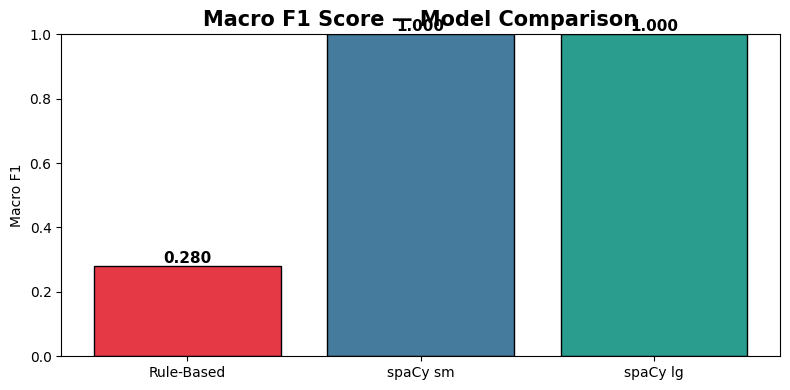

In [ ]:
plt.figure(figsize=(8, 4))
colors = ['#E63946', '#457B9D', '#2A9D8F']
bars = plt.bar(scores.keys(), scores.values(), color=colors, edgecolor='black')
plt.ylim(0, 1)
plt.title('Macro F1 Score — Model Comparison', fontsize=15, fontweight='bold')
plt.ylabel('Macro F1')
for bar, val in zip(bars, scores.values()):
    plt.text(bar.get_x() + bar.get_width()/2, val + 0.01,
             f'{val:.3f}', ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

In [ ]:
sample_texts = [
    "Barack Obama met Angela Merkel in Berlin to discuss NATO strategies.",
    "Reuters reported that FIFA suspended the Brazilian Football Confederation.",
    "The UN Security Council held an emergency meeting in New York on Friday.",
]

for text in sample_texts:
    doc = nlp_sm(text)
    displacy.render(doc, style="ent", jupyter=True)